# 图表反演

In [1]:
import matplotlib.pyplot as plt
# 设置中文字体支持
import matplotlib.font_manager as fm
# 备选中文字体列表
chinese_fonts = [
    "SimHei",           # Windows
    "Heiti TC",         # macOS
    "WenQuanYi Micro Hei",  # Linux
    "Microsoft YaHei",  # 微软雅黑
    "Arial Unicode MS", # 备选
]

# 获取系统可用字体
available_fonts = {f.name for f in fm.fontManager.ttflist}

# 查找第一个可用的中文字体
for font in chinese_fonts:
    if font in available_fonts:
        plt.rcParams["font.family"] = font
        break

plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

/var/folders/54/bbrbnf8953d7z0fzwhskm0b00000gn/T/ipykernel_76127/626629038.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=1, frameon=False)


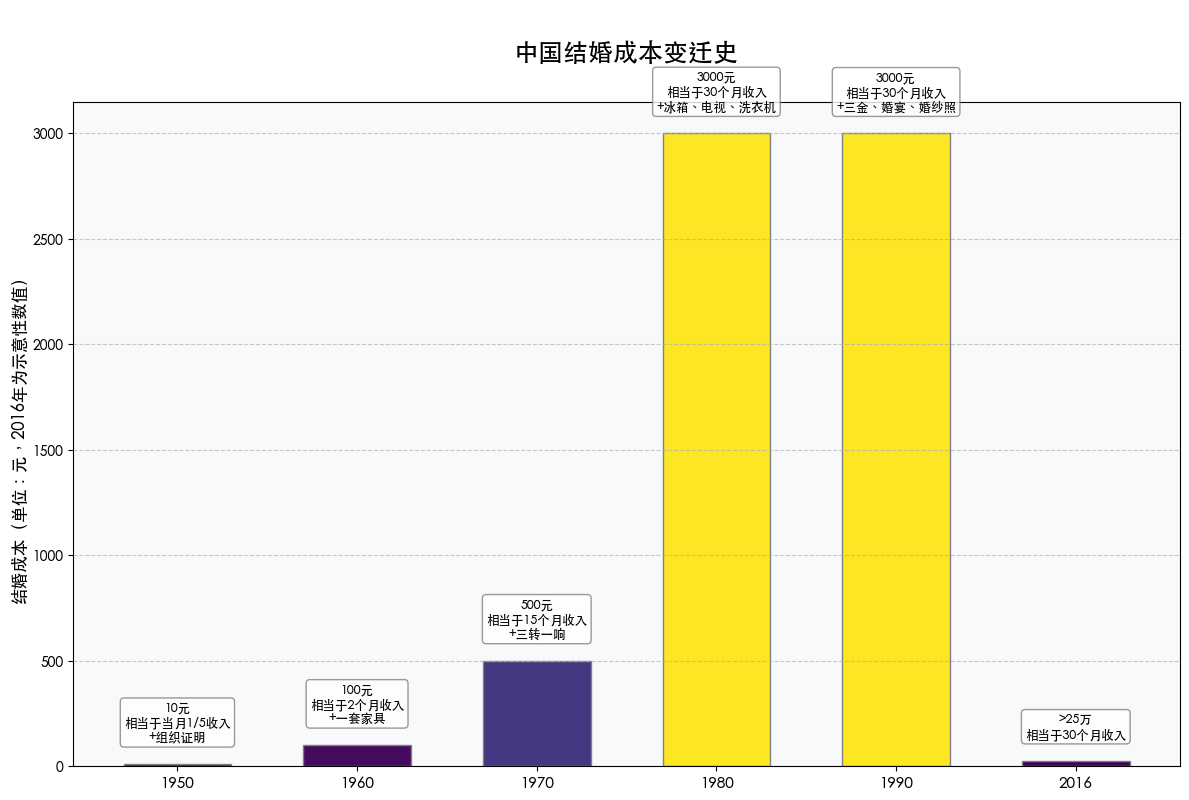

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# 数据定义
years = np.array([1950, 1960, 1970, 1980, 1990, 2016])
costs = np.array([10, 100, 500, 3000, 3000, 25])  # 2016年为示意性数值
labels = [
    "10元\n相当于当月1/5收入\n+组织证明",
    "100元\n相当于2个月收入\n+一套家具",
    "500元\n相当于15个月收入\n+三转一响",
    "3000元\n相当于30个月收入\n+冰箱、电视、洗衣机",
    "3000元\n相当于30个月收入\n+三金、婚宴、婚纱照",
    ">25万\n相当于30个月收入"
]

# 创建图形和坐标轴，增加顶部空间
fig, ax = plt.subplots(figsize=(12, 8))
fig.subplots_adjust(top=0.85)  # 调整顶部间距

# 绘制渐变色柱状图（使用颜色映射）
cmap = plt.cm.viridis
norm = plt.Normalize(min(costs), max(costs))
colors = [cmap(norm(c)) for c in costs]
bars = ax.bar(np.arange(len(years)), costs, width=0.6, color=colors, edgecolor='gray')

# 设置标题和标签
ax.set_title("中国结婚成本变迁史", fontsize=18, fontweight='bold', pad=30)
ax.set_ylabel("结婚成本（单位：元，2016年为示意性数值）", fontsize=12)
ax.set_xticks(np.arange(len(years)))
ax.set_xticklabels(years, fontsize=11)

# 添加网格线和背景色
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_facecolor('#f8f9fa')

# 优化文本标注 - 使用方框标注替代直接在柱上标注
for i, (bar, label) in enumerate(zip(bars, labels)):
    height = bar.get_height()
    ax.annotate(label,
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 15),  # 垂直偏移
                textcoords="offset points",
                ha='center', va='bottom',
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8),
                fontsize=9)

# 添加图例说明
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=1, frameon=False)

plt.tight_layout()
plt.show()

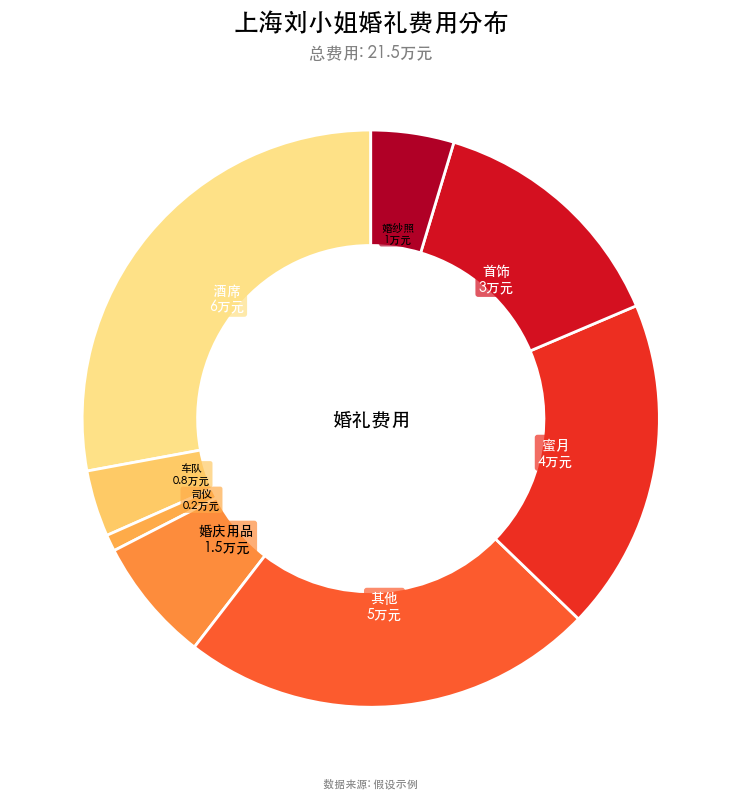

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# 数据定义
labels = ["酒席", "车队", "司仪", "婚庆用品", "其他", "蜜月", "首饰", "婚纱照"]
sizes = [6, 0.8, 0.2, 1.5, 5, 4, 3, 1]
total_cost = sum(sizes)  # 总费用

# 优化的颜色方案（使用更协调的渐变色）
colors = plt.cm.YlOrRd(np.linspace(0.2, 0.9, len(labels)))

# 创建画布和子图
fig, ax = plt.subplots(figsize=(10, 8))

# 绘制环形图（donut chart）
wedges, texts, autotexts = ax.pie(
    sizes, 
    labels=None,  # 不在图上直接显示标签
    colors=colors,
    autopct='',  # 先不显示数值
    startangle=90,
    wedgeprops=dict(width=0.4, edgecolor='w', linewidth=2),  # 增加环形宽度和白色边框
)

# 自定义标签：同时显示名称和金额，并智能调整位置和颜色
for i, (wedge, label, size) in enumerate(zip(wedges, labels, sizes)):
    # 计算文本位置
    theta = (wedge.theta2 + wedge.theta1) / 2
    x = 0.65 * np.cos(np.radians(theta))  # 0.65控制径向位置
    y = 0.65 * np.sin(np.radians(theta))
    
    # 根据扇形大小调整文本样式
    text_size = 10 if size / total_cost > 0.05 else 8  # 小扇形用更小字体
    
    # 文本内容
    text = f"{label}\n{size}万元"
    
    # 调整文本颜色（深色扇形用白色文本，浅色扇形用黑色文本）
    color = 'white' if i in [0, 4, 5, 6] else 'black'
    
    # 添加文本
    ax.text(x, y, text, ha='center', va='center', fontsize=text_size, 
            fontweight='bold', color=color, bbox=dict(
                boxstyle="round,pad=0.2", 
                fc=colors[i], 
                ec='none', 
                alpha=0.7
            ))

# 设置标题
ax.set_title("上海刘小姐婚礼费用分布", fontsize=18, fontweight='bold', pad=20)
subtitle = f"总费用: {total_cost}万元"
plt.figtext(0.5, 0.92, subtitle, ha='center', fontsize=12, color='gray')

# 添加中心文本
centre_circle = plt.Circle((0, 0), 0.2, fc='white')
ax.add_patch(centre_circle)
ax.text(0, 0, "婚礼费用", ha='center', va='center', fontsize=14, fontweight='bold')

# 调整布局
plt.tight_layout()

# 添加数据来源
plt.figtext(0.5, 0.01, "数据来源: 假设示例", ha='center', fontsize=8, color='gray')

plt.show()

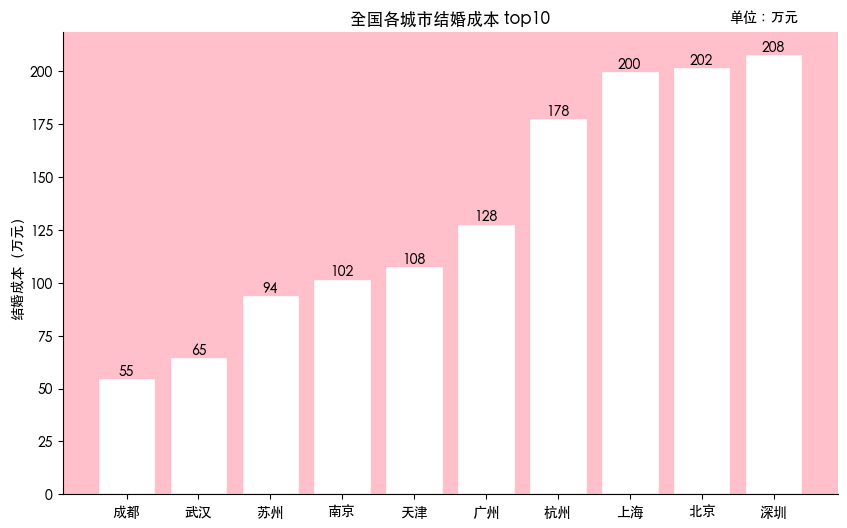

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# 城市名称
cities = ["成都", "武汉", "苏州", "南京", "天津", "广州", "杭州", "上海", "北京", "深圳"]
# 结婚成本（单位：万元）
costs = [55, 65, 94, 102, 108, 128, 178, 200, 202, 208]

x = np.arange(len(cities))  # 用于设置柱状图 x 轴的位置

# 创建画布和轴对象
fig, ax = plt.subplots(figsize=(10, 6))
# 绘制柱状图，设置颜色为白色，边框为粉色
bars = ax.bar(x, costs, color='white', edgecolor='pink')

# 设置 x 轴刻度和标签
ax.set_xticks(x)
ax.set_xticklabels(cities)
# 设置 y 轴标签
ax.set_ylabel("结婚成本（万元）")
# 设置标题
ax.set_title("全国各城市结婚成本 top10")
# 设置单位显示在标题旁
ax.text(0.95, 1.02, "单位：万元", transform=ax.transAxes, ha='right', va='bottom')

# 在每个柱子上标注数值
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height, f'{height}',
            ha='center', va='bottom')

# 设置背景颜色为粉色
ax.set_facecolor('pink')
# 去除顶部和右侧边框
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.show()

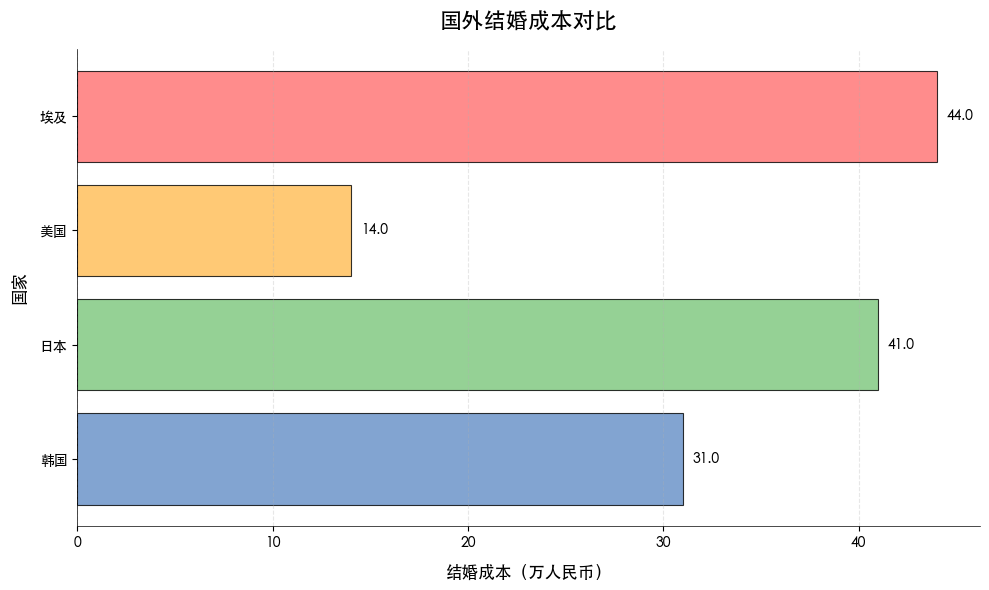

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# 数据
countries = ["韩国", "日本", "美国", "埃及"]
costs = [31, 41, (11 + 17) / 2, 44]  # 美国取区间平均值

# 颜色方案
colors = ['#638EC6', '#7BC67B', '#FFBC52', '#FF6F6F']

# 创建画布和子图
fig, ax = plt.subplots(figsize=(10, 6))

# 绘制横向柱状图，添加透明度和边框
bars = ax.barh(countries, costs, color=colors, alpha=0.8, edgecolor='black', linewidth=0.8)

# 添加标题和标签
ax.set_title("国外结婚成本对比", fontsize=16, pad=15)
ax.set_xlabel("结婚成本（万人民币）", fontsize=12, labelpad=10)
ax.set_ylabel("国家", fontsize=12, labelpad=10)

# 添加数值标签
for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.5, bar.get_y() + bar.get_height()/2,
            f'{width:.1f}', ha='left', va='center', fontsize=10)

# 设置坐标轴样式
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)

# 设置刻度样式
ax.tick_params(axis='both', which='major', labelsize=10)
ax.xaxis.grid(True, linestyle='--', alpha=0.7)

# 添加背景网格
plt.grid(axis='x', linestyle='--', alpha=0.3)

# 调整布局
plt.tight_layout()

# 显示图表
plt.show()    